##### ARTI 560 - Computer Vision

## Instance Segmentation - Exercise 

### Objective

In this exercise, you will implement **Instance Object Segmentation** using a pretrained **Mask R-CNN model** from TensorFlow Hub.

You will follow these steps:

1. **Load the pretrained Mask R-CNN model**  
   - Use this Kaggle link: [Mask R-CNN Inception-ResNet-v2](https://www.kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2)  

2. **Select and load 5 different images**  
   - Choose **5 diverse images**, including:  
      - Crowded scenes with multiple objects  
      - Unusual angles, lighting conditions, or occlusions  
      - At least **one image containing multiple objects of the same class** 

3. **Perform inference using the model**  
   - Feed images to the model to obtain predictions  

4. **Extract prediction outputs**  
   - **Bounding boxes** – coordinates of detected objects  
   - **Class labels** – names of detected objects  
   - **Segmentation masks** – pixel-wise masks for each object  

5. **Visualize the results**  
   - Overlay masks on detected objects  
   - Draw bounding boxes around objects  
   - Display class names and confidence scores  

6. **Experiment with confidence thresholds**  
   - Default threshold: **0.5**  
   - Lower threshold: **0.3** to detect more objects (may include false positives)  

---

- Keep in mind:  
  - Some objects may not be recognized at the default threshold 
  - The model only detects objects from the **COCO dataset (80 classes)**  


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tensorflow as tf
import tensorflow_hub as hub
import requests
from PIL import Image
from io import BytesIO

In [6]:
#load pretrained mask rcnn
import os
MODEL_PATH = "/Users/ykalsuhaili/Documents/GitHub/arti560-computer-vision-labs/lab05-object-segmentation/mask-rcnn-inception-resnet-v2-tensorflow2-1024x1024-v1"

print("loading model")
detector = hub.load(MODEL_PATH)
print("done!")

loading model
done!


In [7]:
COCO_LABELS = [
    'background', 'person', 'bicycle', 'car', 'motorcycle', 'airplane',
    'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack',
    'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
    'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed',
    'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote',
    'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink',
    'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear',
    'hair drier', 'toothbrush'
]

In [8]:
# for loading images i chose
def load_local_image(path):
    """Load a local image file as RGB numpy array."""
    img = Image.open(path).convert("RGB")
    return np.array(img)

def prepare_image(image_np):
    """Resize and prepare image tensor for the model."""
    img_resized = tf.image.resize(image_np, (1024, 1024))
    img_tensor = tf.cast(img_resized, tf.uint8)
    return img_tensor[tf.newaxis, ...]  # add batch dimension

In [9]:
#image files i chose
image_paths = {
    "1": "cars_lab5.png",
    "2": "furniture_lab5.png",
    "3": "lighting_lab5.png",
    "4": "multiple_lab5.png",
    "5": "occlusions_lab5.png",
}

images = {}
for name, path in image_paths.items():
    try:
        images[name] = load_local_image(path)
        print(f"loaded: {name} — shape: {images[name].shape}")
    except Exception as e:
        print(f"failed to load {name}: {e}")

loaded: 1 — shape: (675, 1200, 3)
loaded: 2 — shape: (1004, 1400, 3)
loaded: 3 — shape: (360, 640, 3)
loaded: 4 — shape: (720, 1200, 3)
loaded: 5 — shape: (720, 1080, 3)


In [10]:
def run_inference(model, image_np):
    input_tensor = prepare_image(image_np)
    result = model(input_tensor)
    return {k: v.numpy() for k, v in result.items()}

print("running inference on all images")
results = {}
for name, img in images.items():
    print(f"  Processing: {name}")
    results[name] = run_inference(detector, img)
print("Done!")

running inference on all images
  Processing: 1
  Processing: 2
  Processing: 3
  Processing: 4
  Processing: 5
Done!


In [16]:
def visualize_predictions(image_np, result, image_title, threshold=0.5):
    boxes   = result['detection_boxes'][0]
    scores  = result['detection_scores'][0]
    classes = result['detection_classes'][0].astype(int)
    masks   = result['detection_masks'][0]  # (100, 33, 33)

    h, w = image_np.shape[:2]
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))

    overlay = image_np.copy().astype(np.float32) / 255.0

    np.random.seed(42)
    colors = np.random.rand(100, 3)
    
    detection_count = 0
    for i in range(len(scores)):
        if scores[i] < threshold:
            continue
        detection_count += 1

        score   = scores[i]
        cls     = classes[i]
        label   = COCO_LABELS[cls] if cls < len(COCO_LABELS) else f"class_{cls}"
        color   = colors[i]

        # Bbox
        ymin, xmin, ymax, xmax = boxes[i]
        x1 = int(xmin * w)
        y1 = int(ymin * h)
        bw = int((xmax - xmin) * w)
        bh = int((ymax - ymin) * h)

        # resize
        mask = masks[i]  # (33, 33)
        mask_resized = tf.image.resize(
            mask[..., tf.newaxis],
            (h, w),
            method='bilinear'
        ).numpy()[..., 0]
        mask_binary = mask_resized > 0.5

        # apply colored mask overlay
        for c in range(3):
            overlay[:, :, c] = np.where(
                mask_binary,
                overlay[:, :, c] * 0.5 + color[c] * 0.5,
                overlay[:, :, c]
            )

    # show overlay
    ax.imshow(overlay)

    # draw boxes and labels on top
    for i in range(len(scores)):
        if scores[i] < threshold:
            continue
        color   = colors[i]
        cls     = classes[i]
        label   = COCO_LABELS[cls] if cls < len(COCO_LABELS) else f"class_{cls}"
        ymin, xmin, ymax, xmax = boxes[i]
        x1 = int(xmin * w)
        y1 = int(ymin * h)
        bw = int((xmax - xmin) * w)
        bh = int((ymax - ymin) * h)

        rect = patches.Rectangle(
            (x1, y1), bw, bh,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(
            x1, max(y1 - 5, 0),
            f"{label}: {scores[i]:.2f}",
            color='white', fontsize=9, fontweight='bold',
            bbox=dict(facecolor=color, alpha=0.7, pad=2, edgecolor='none')
        )

    ax.set_title(
        f"{image_title}  [threshold={threshold}]  —  {detection_count} detections",
        fontsize=13, fontweight='bold'
    )
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    print(f"  → {detection_count} objects detected above threshold {threshold}")

RESULTS — confidence threshold: 0.5


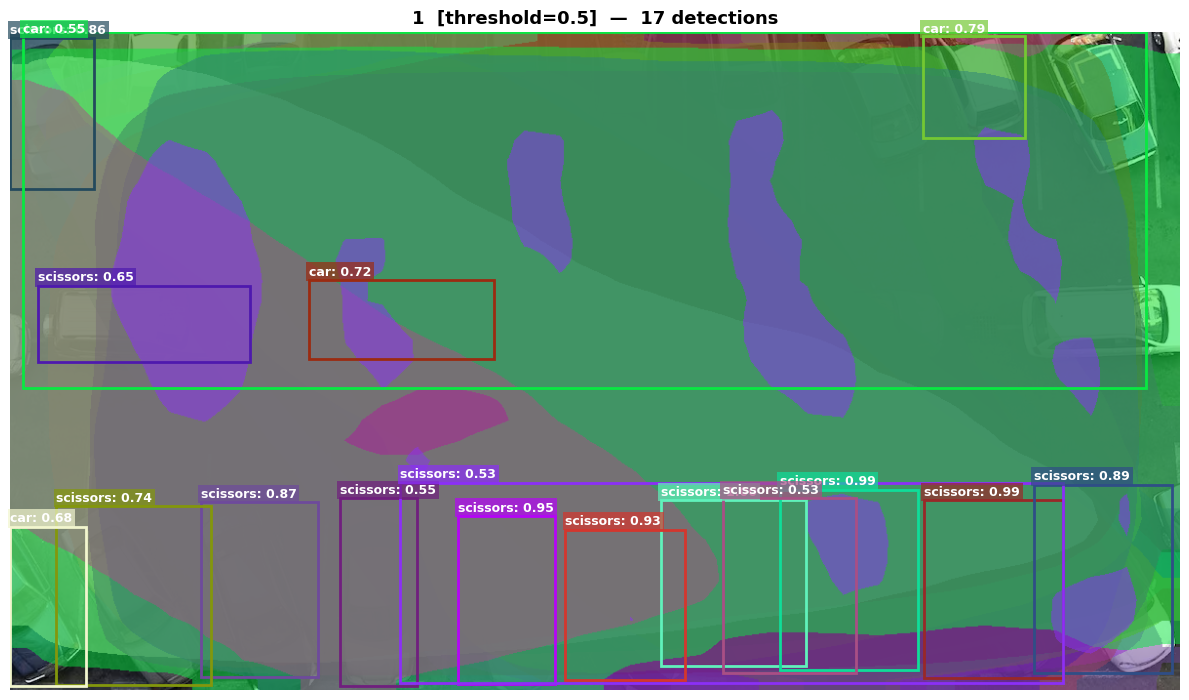

  → 17 objects detected above threshold 0.5


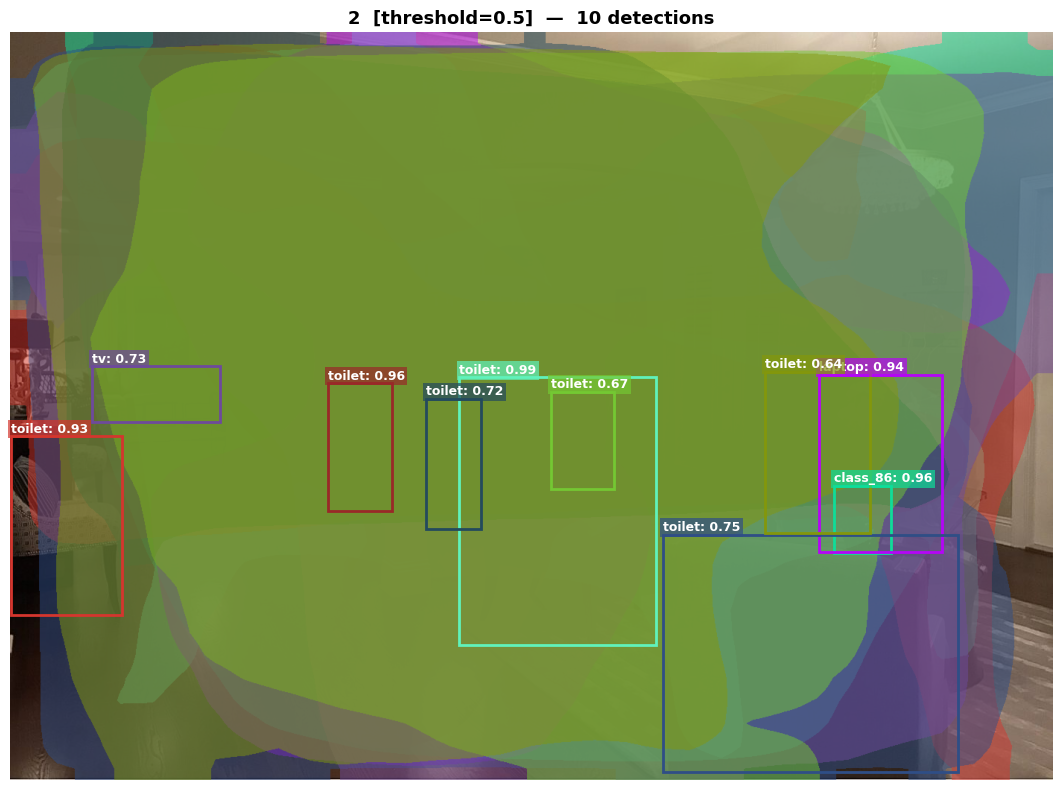

  → 10 objects detected above threshold 0.5


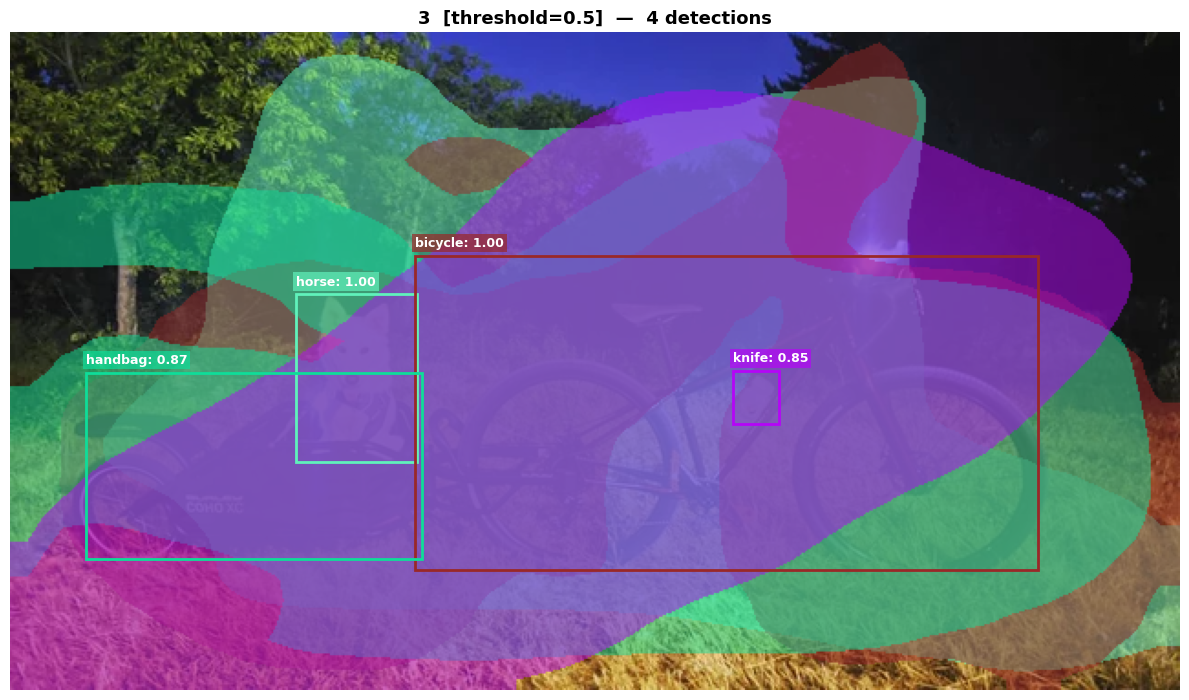

  → 4 objects detected above threshold 0.5


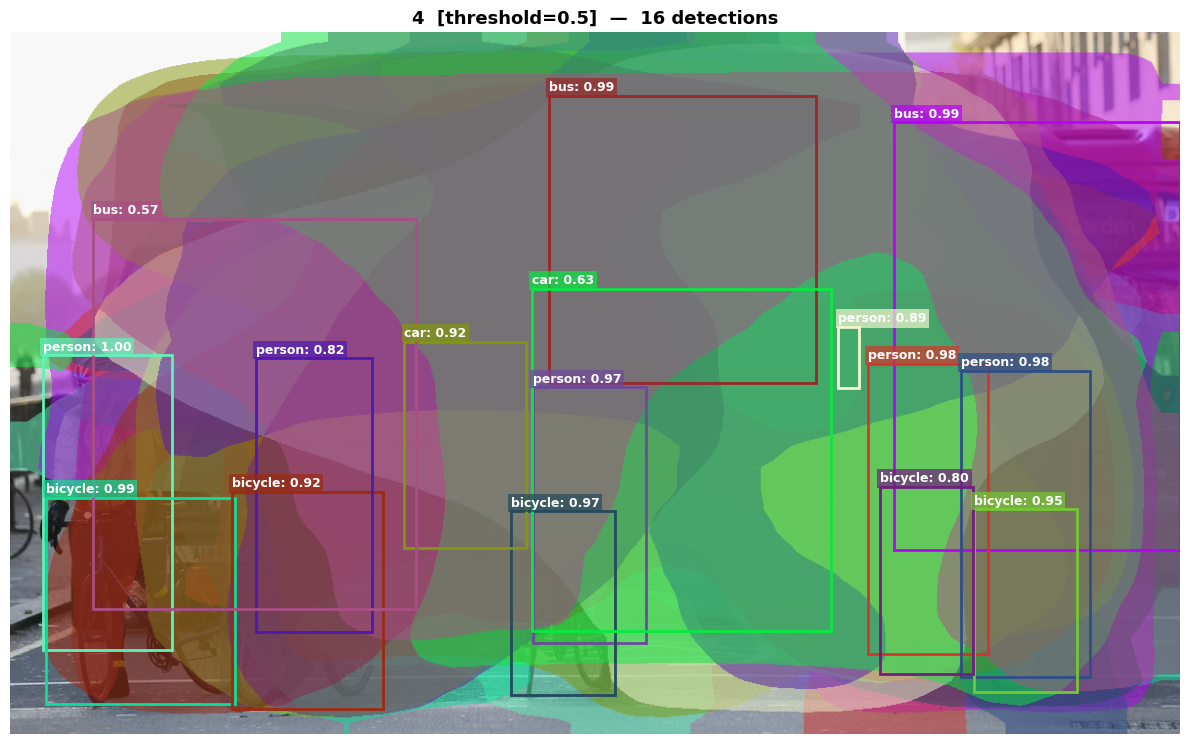

  → 16 objects detected above threshold 0.5


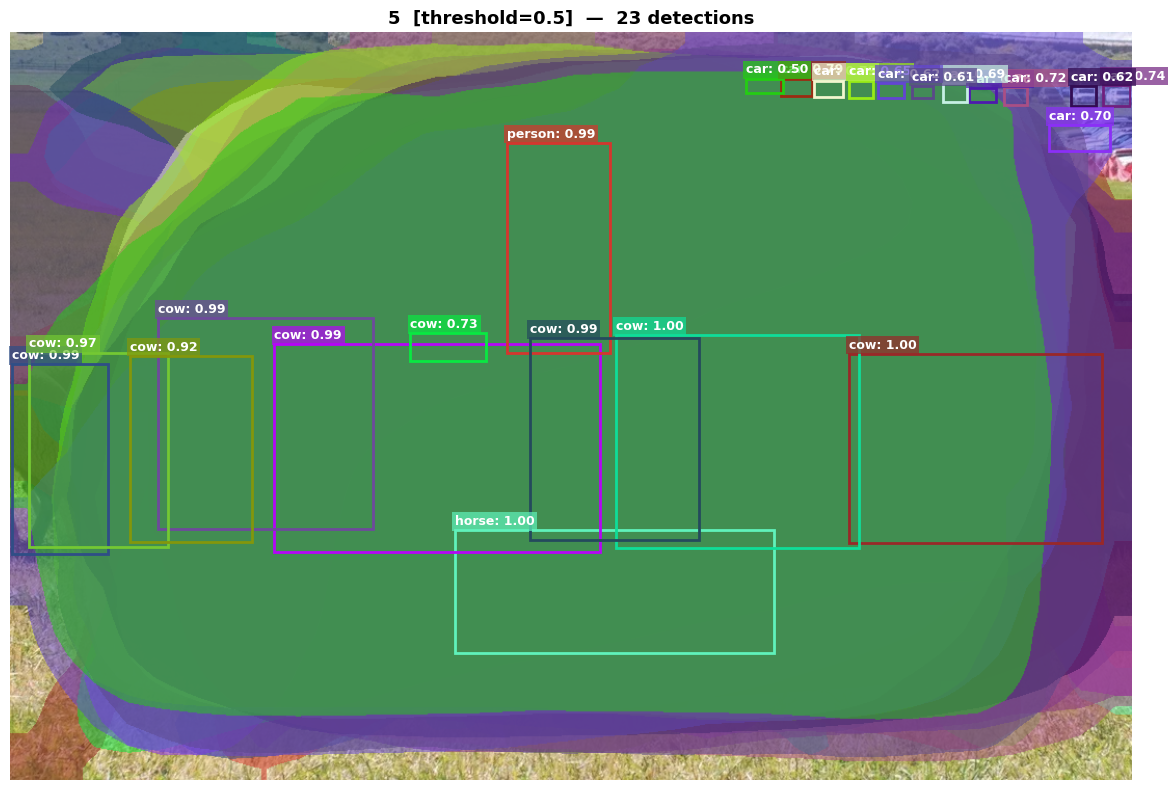

  → 23 objects detected above threshold 0.5


In [17]:
print("RESULTS — confidence threshold: 0.5")

for name, img in images.items():
    visualize_predictions(img, results[name], image_title=name, threshold=0.5)

RESULTS — confidence threshold: 0.3


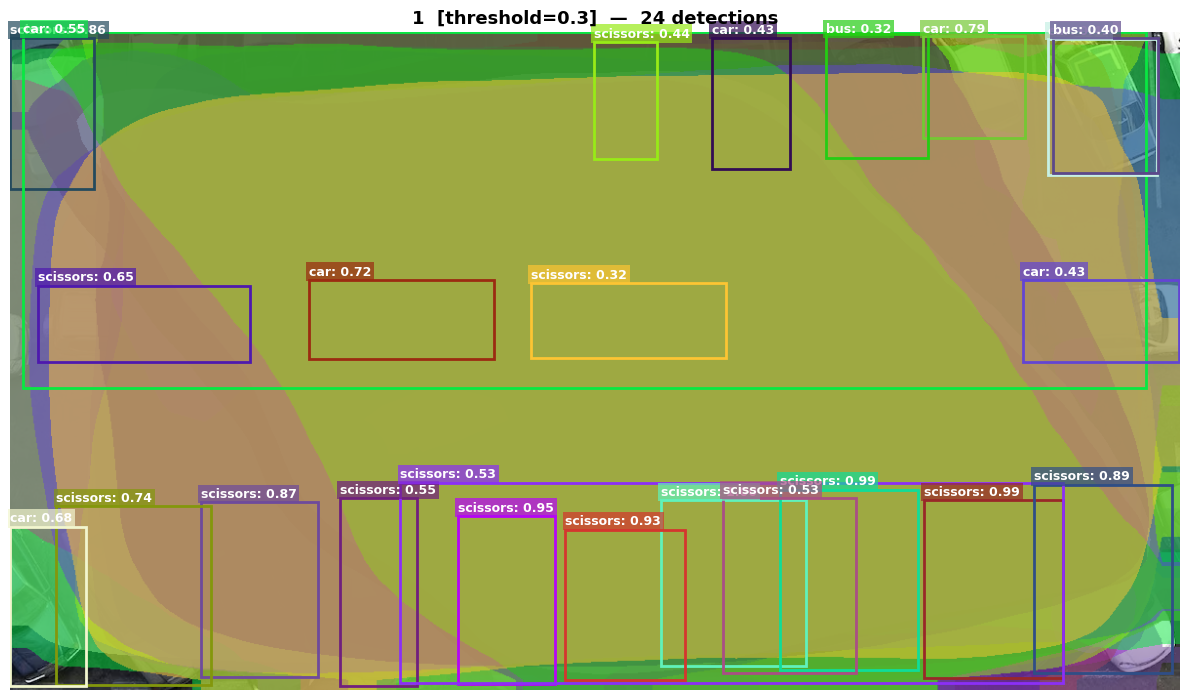

  → 24 objects detected above threshold 0.3


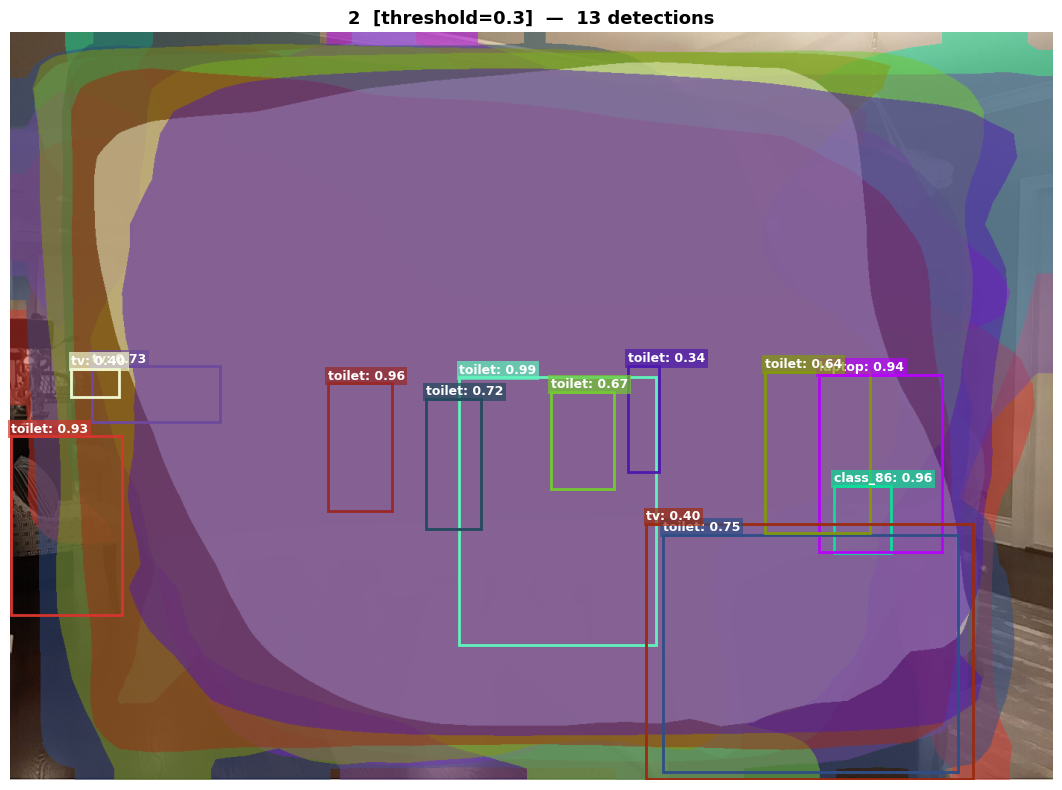

  → 13 objects detected above threshold 0.3


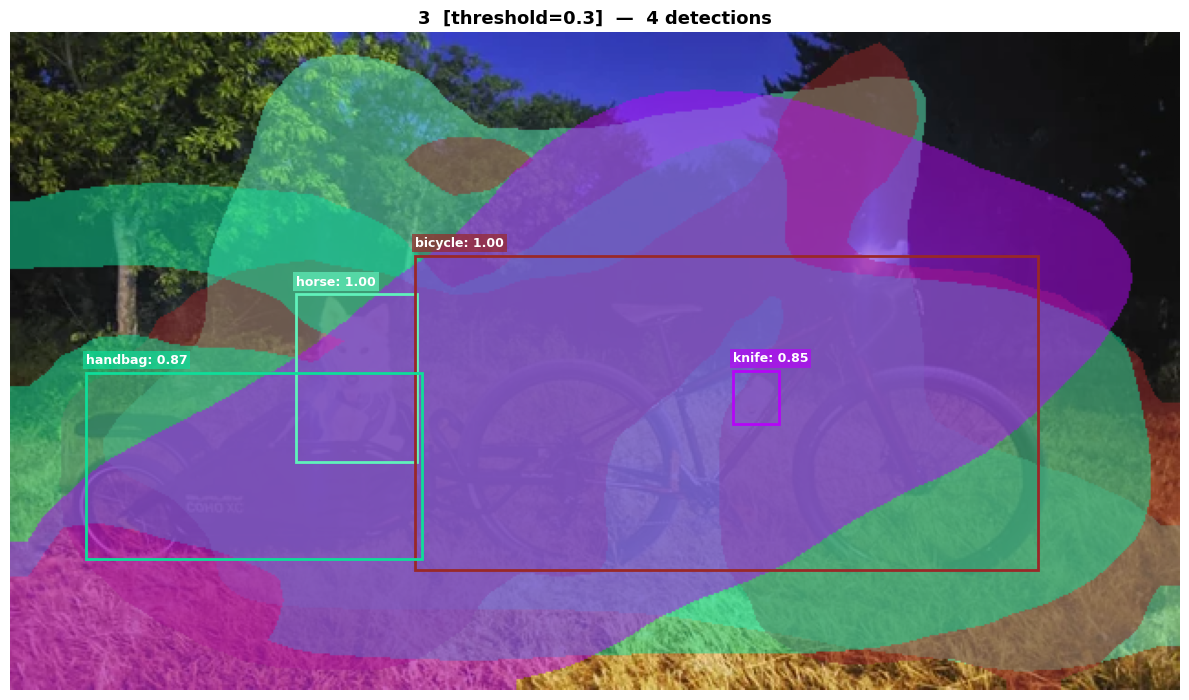

  → 4 objects detected above threshold 0.3


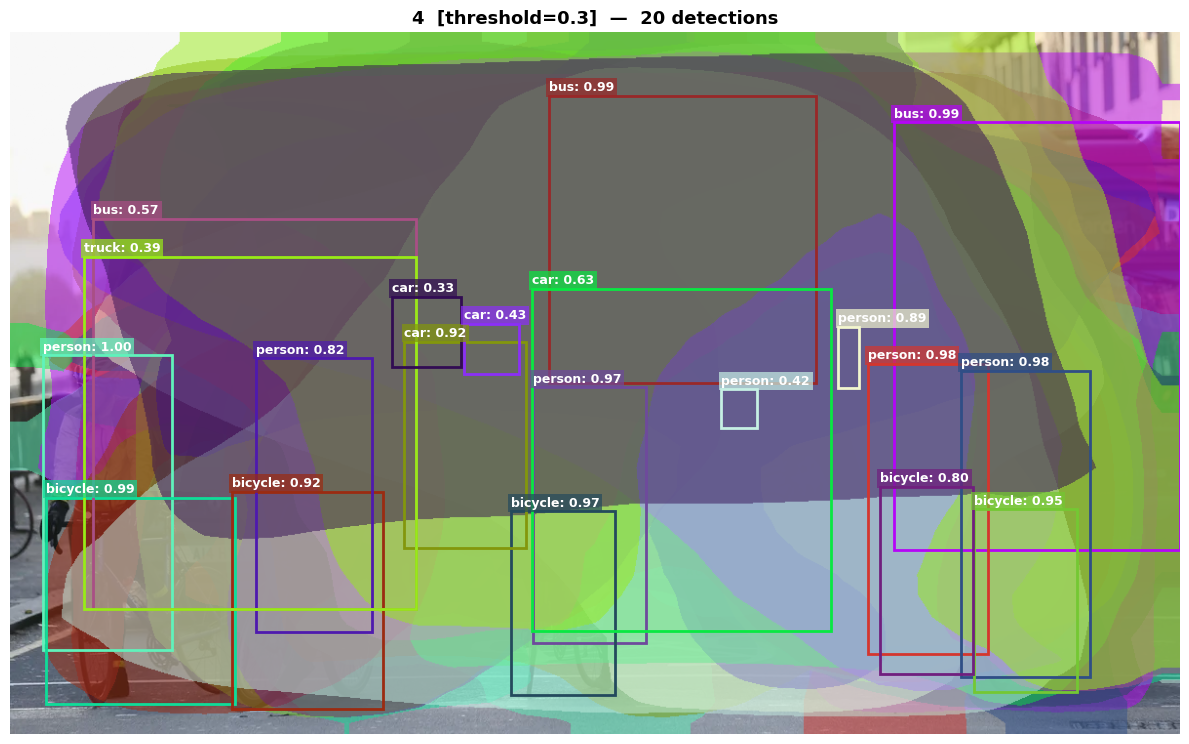

  → 20 objects detected above threshold 0.3


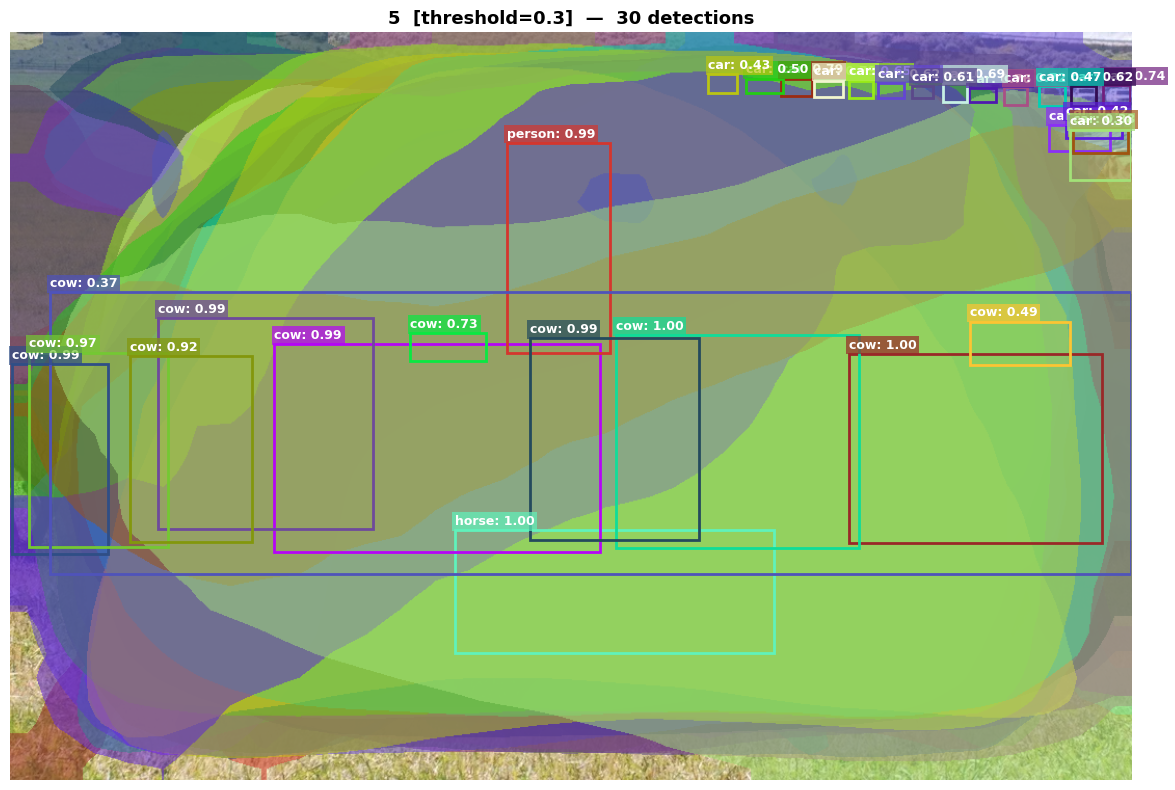

  → 30 objects detected above threshold 0.3


In [19]:
print("RESULTS — confidence threshold: 0.3")

for name, img in images.items():
    visualize_predictions(img, results[name], image_title=name, threshold=0.3)

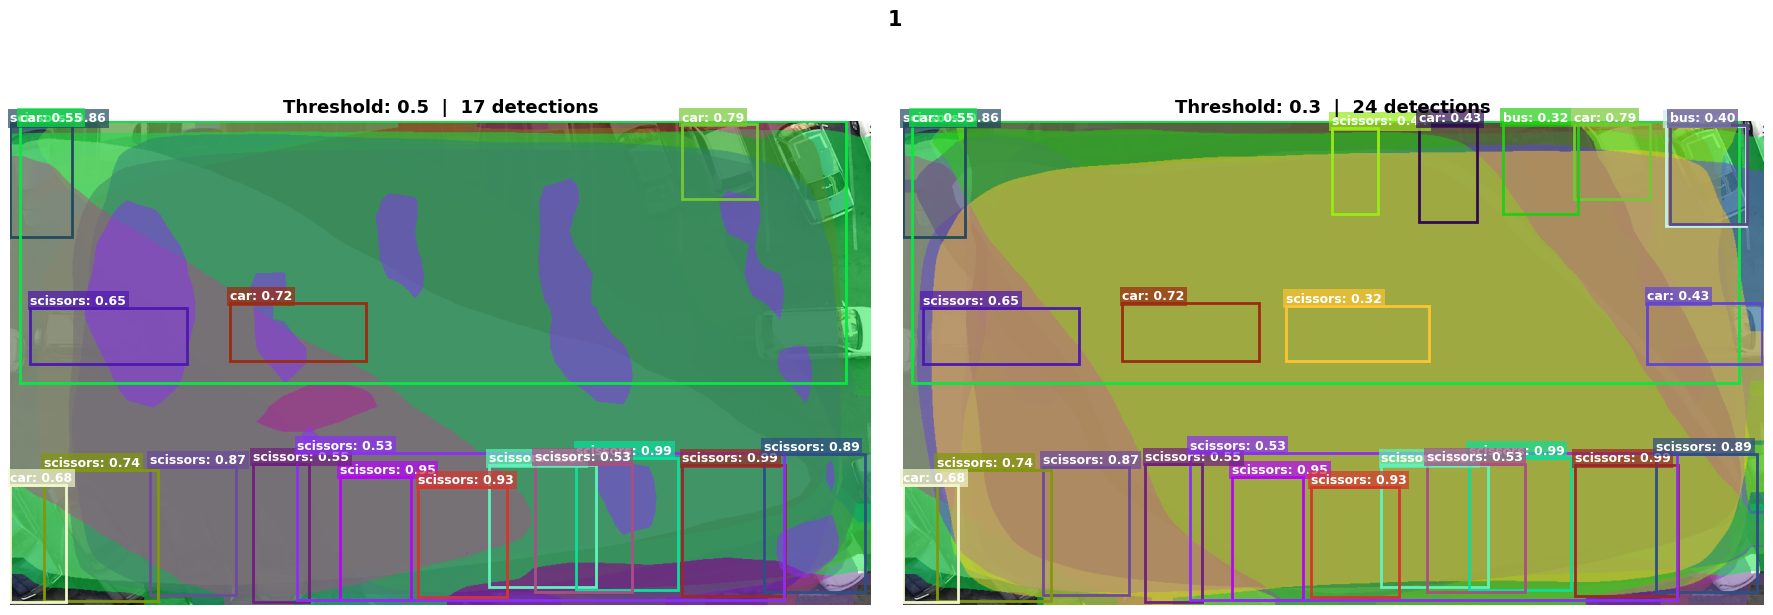

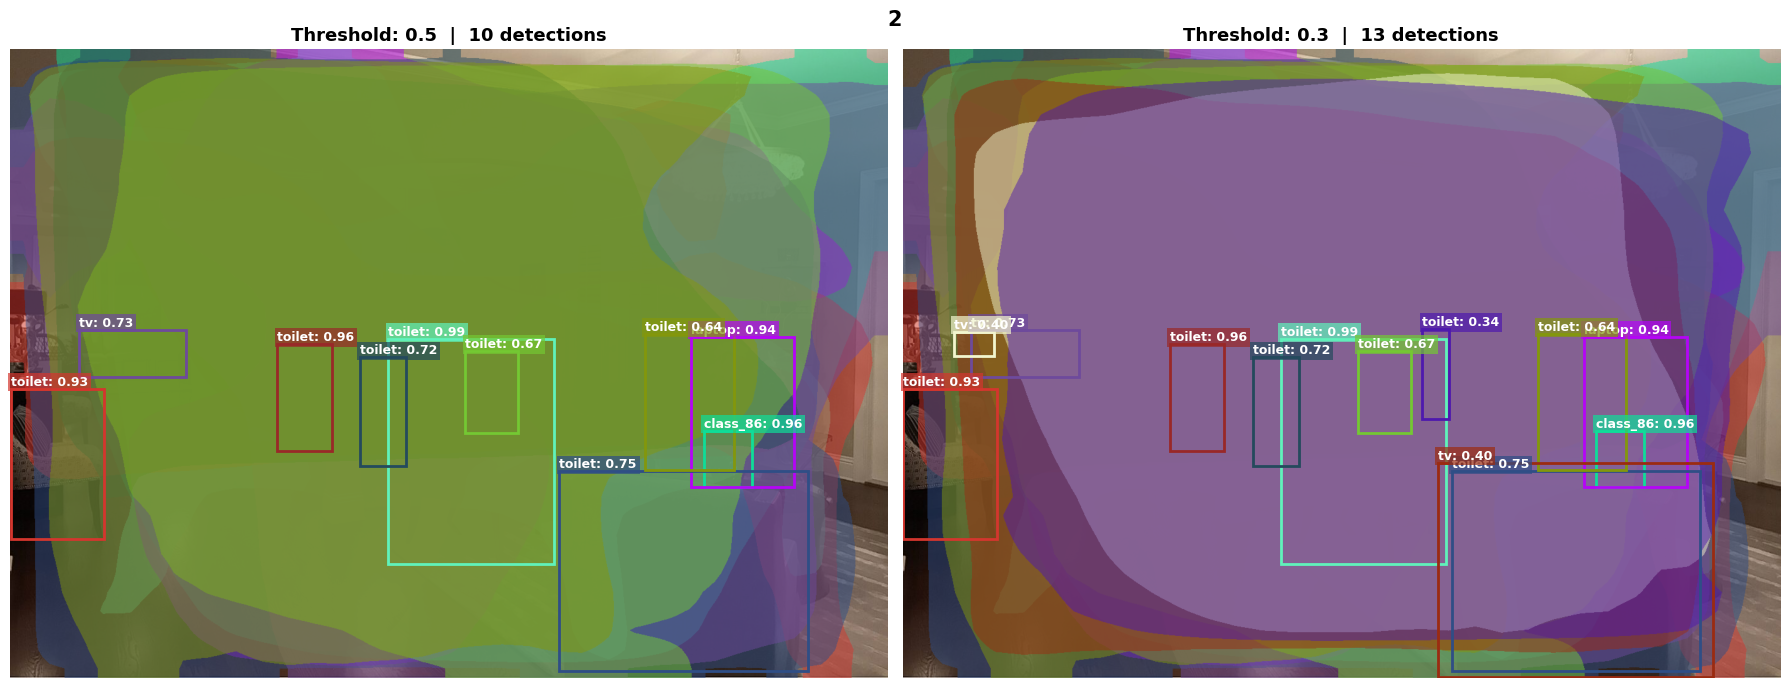

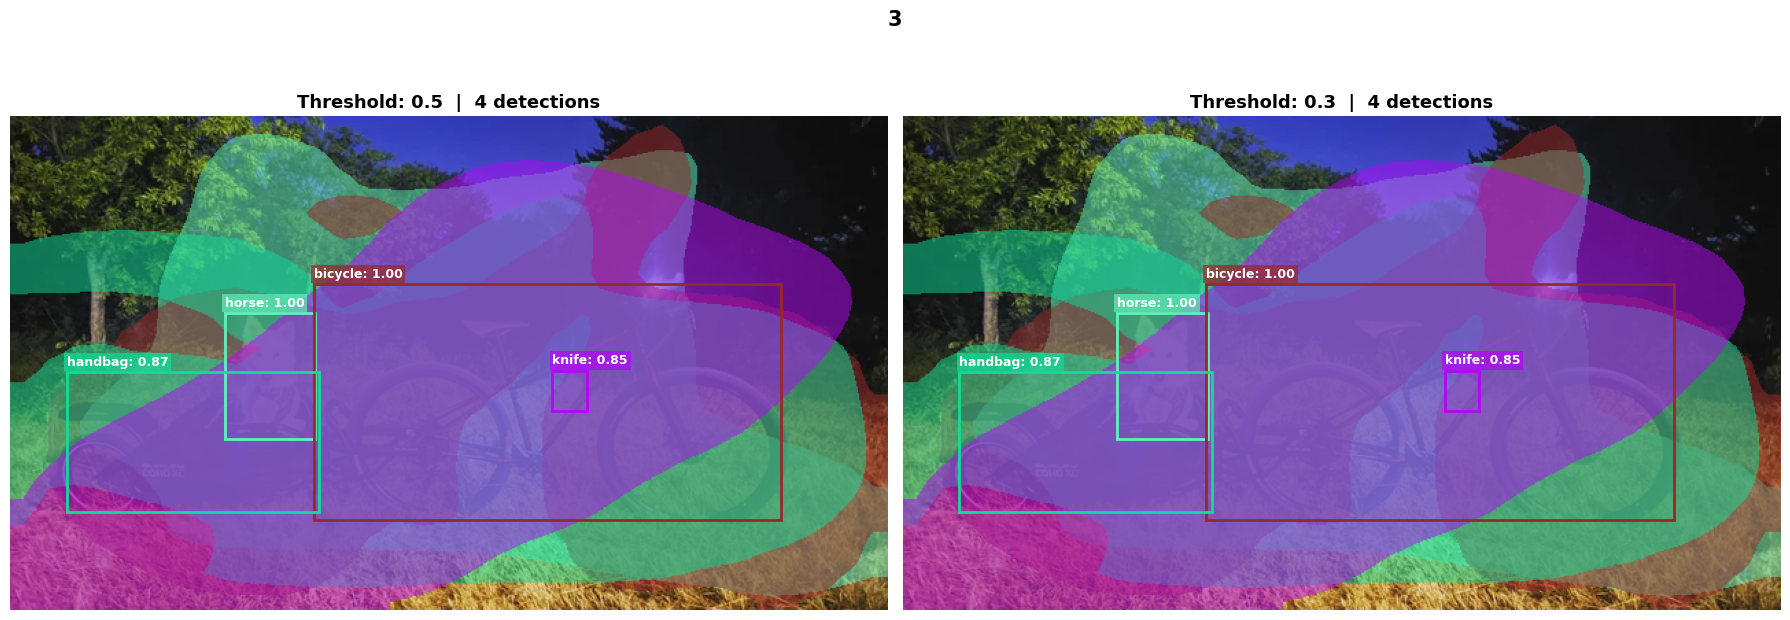

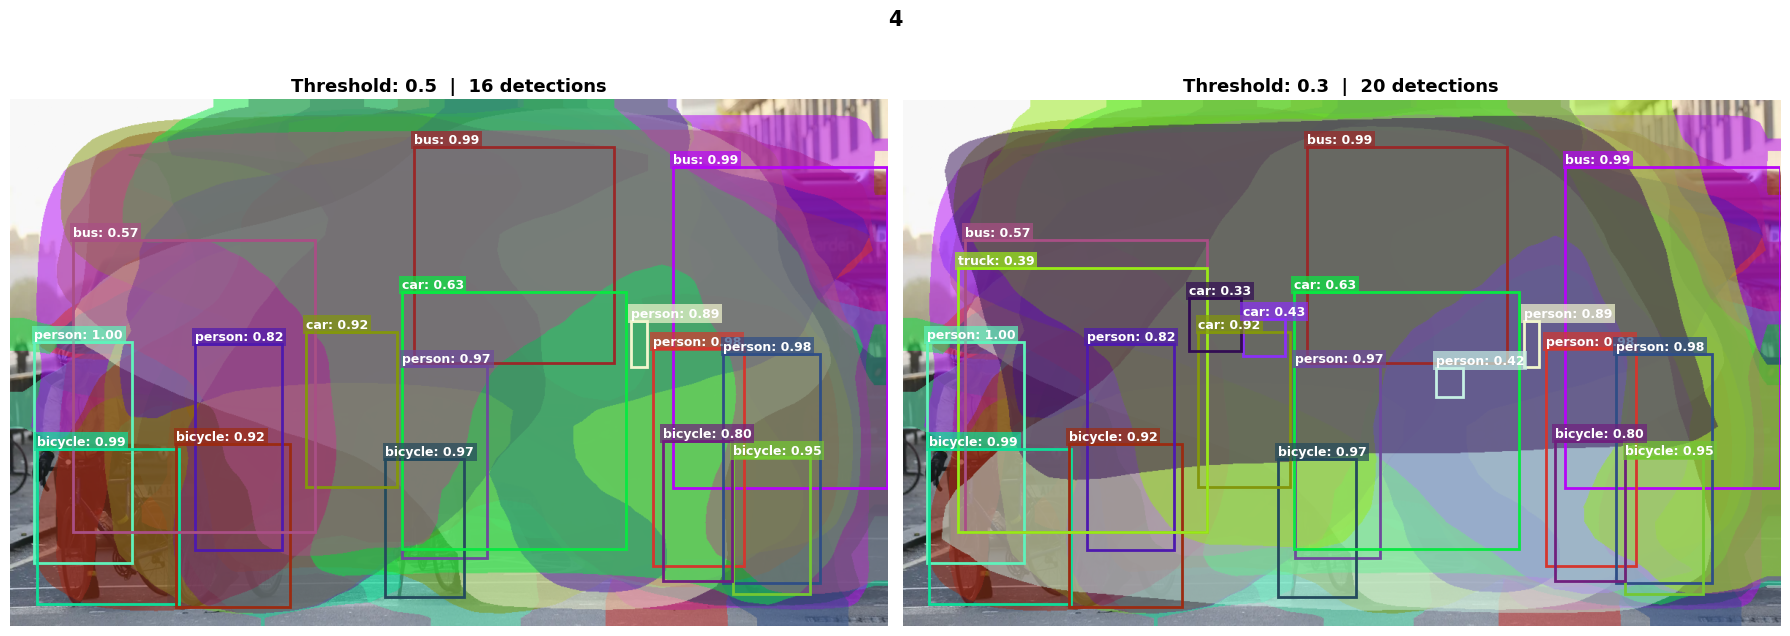

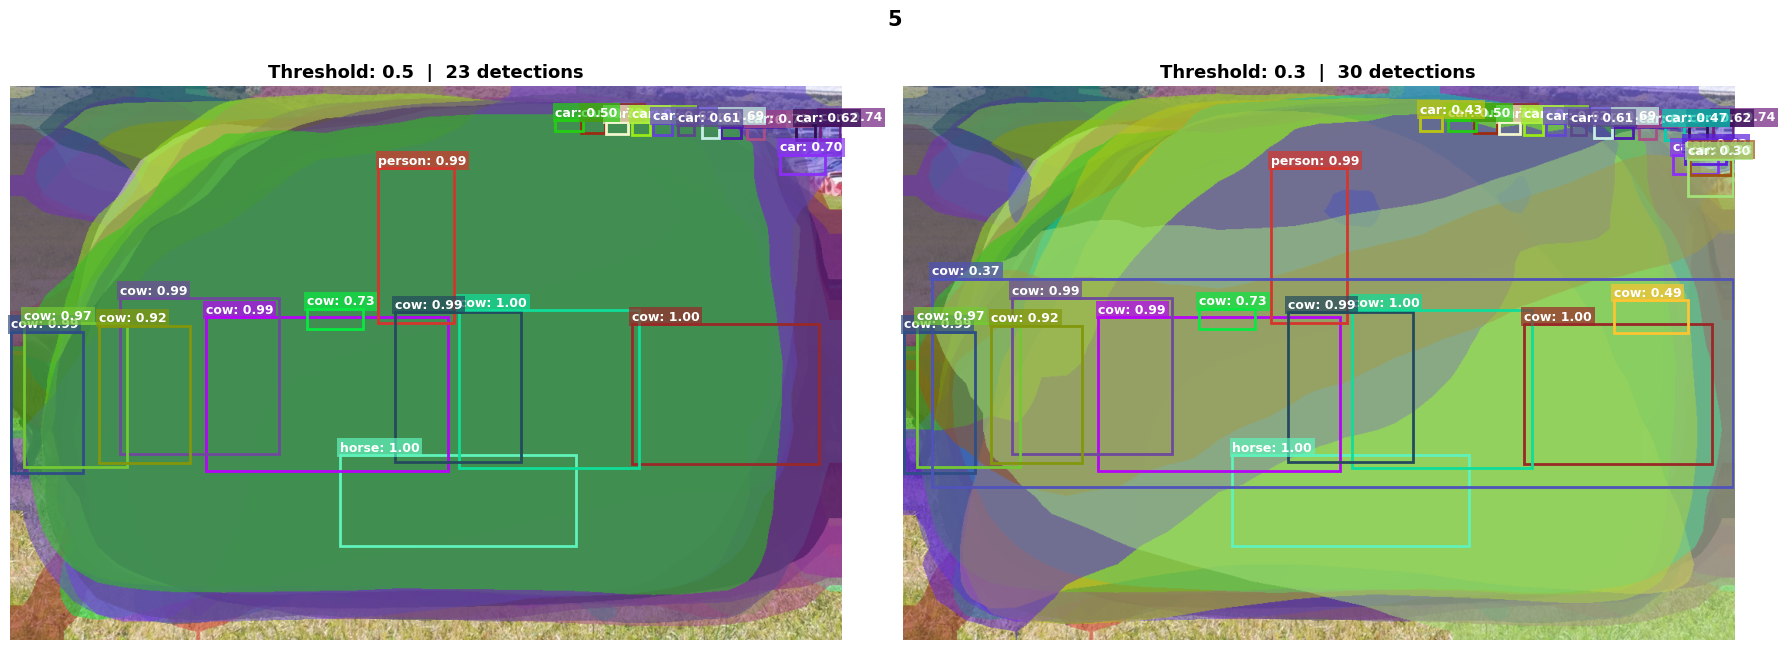

In [22]:
def compare_thresholds(image_np, result, image_title):
    boxes   = result['detection_boxes'][0]
    scores  = result['detection_scores'][0]
    classes = result['detection_classes'][0].astype(int)
    masks   = result['detection_masks'][0]

    h, w = image_np.shape[:2]
    np.random.seed(42)
    colors = np.random.rand(100, 3)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    for ax, threshold in zip(axes, [0.5, 0.3]):
        overlay = image_np.copy().astype(np.float32) / 255.0

        detection_count = 0
        for i in range(len(scores)):
            if scores[i] < threshold:
                continue
            detection_count += 1
            color = colors[i]

            # resize
            mask = masks[i]
            mask_resized = tf.image.resize(
                mask[..., tf.newaxis], (h, w), method='bilinear'
            ).numpy()[..., 0]
            mask_binary = mask_resized > 0.5

            for c in range(3):
                overlay[:, :, c] = np.where(
                    mask_binary,
                    overlay[:, :, c] * 0.5 + color[c] * 0.5,
                    overlay[:, :, c]
                )

        ax.imshow(overlay)

        # boxes and labels
        for i in range(len(scores)):
            if scores[i] < threshold:
                continue
            color = colors[i]
            cls   = classes[i]
            label = COCO_LABELS[cls] if cls < len(COCO_LABELS) else f"class_{cls}"
            ymin, xmin, ymax, xmax = boxes[i]
            x1 = int(xmin * w)
            y1 = int(ymin * h)
            bw = int((xmax - xmin) * w)
            bh = int((ymax - ymin) * h)

            rect = patches.Rectangle(
                (x1, y1), bw, bh,
                linewidth=2, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(
                x1, max(y1 - 5, 0),
                f"{label}: {scores[i]:.2f}",
                color='white', fontsize=9, fontweight='bold',
                bbox=dict(facecolor=color, alpha=0.7, pad=2, edgecolor='none')
            )

        ax.set_title(
            f"Threshold: {threshold}  |  {detection_count} detections",
            fontsize=13, fontweight='bold'
        )
        ax.axis('off')

    plt.suptitle(image_title, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

for name, img in images.items():
    compare_thresholds(img, results[name], image_title=name)